# Chicago crime data: enhanced visual analysis

A companion solution to the exercise. It adds data-quality checks, rate-based comparisons, readable top-N views, robust geographic cleaning, and conclusions computed from the data. Counts describe recorded incidents, not underlying crime prevalence or causality.

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

## 1. Load and prepare

Put the CSV in `resources/` or change `DATA_PATH`. Dates that cannot be parsed are excluded, so all time-based charts use valid timestamps.

In [4]:
DATA_PATH = next((p for p in (Path('resources/Crimes_-_2001_to_present.csv'), Path('Crimes_-_2001_to_present.csv')) if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('CSV not found. Put Crimes_-_2001_to_present.csv beside this notebook or in resources/.')
df = pd.read_csv(DATA_PATH, low_memory=False)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']).copy()
df['month'] = df['Date'].dt.to_period('M').dt.to_timestamp()
df['week'] = df['Date'].dt.to_period('W').dt.start_time
print(f'{len(df):,} usable records, {df.Date.min():%Y-%m-%d} to {df.Date.max():%Y-%m-%d}.')

6,492,089 usable records, 2001-01-01 to 2017-12-01.


## 2. Column types, missingness, and cardinality

This answers the feature-inventory question and makes missing categorical columns explicit.

In [3]:
profile = pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing': df.isna().sum(), 'missing_%': (100 * df.isna().mean()).round(2), 'unique_non_null': df.nunique(dropna=True)}).sort_values(['missing_%', 'unique_non_null'], ascending=[False, False])
display(profile)
numeric_columns = df.select_dtypes(include='number').columns.tolist()
categorical_with_missing = profile.index[(profile['missing'] > 0) & ~profile.index.isin(numeric_columns)]
display(profile.loc[categorical_with_missing, ['missing', 'missing_%', 'unique_non_null']])
print('Numeric columns:', numeric_columns)

,dtype,missing,missing_%,unique_non_null
Community Area,float64,616029,9.49,78
Ward,float64,614853,9.47,50
Location,str,87471,1.35,850795
Latitude,float64,87471,1.35,849659
Longitude,float64,87471,1.35,849103
Y Coordinate,float64,87471,1.35,129662
X Coordinate,float64,87471,1.35,78406
Location Description,str,3003,0.05,173
ID,int64,0,0.00,6492089
Case Number,str,4,0.00,6491706


,missing,missing_%,unique_non_null
Location,87471,1.35,850795
Location Description,3003,0.05,173
Case Number,4,0.00,6491706


Numeric columns: ['ID', 'Beat', 'District', 'Ward', 'Community Area', 'X Coordinate', 'Y Coordinate', 'Year', 'Latitude', 'Longitude']


## 3. Feature distributions

Identifier-like numeric fields are not treated as continuous measures. Histogram frequencies are log-scaled to expose long tails. Categorical plots include missing values and are capped at 20 labels for legibility.

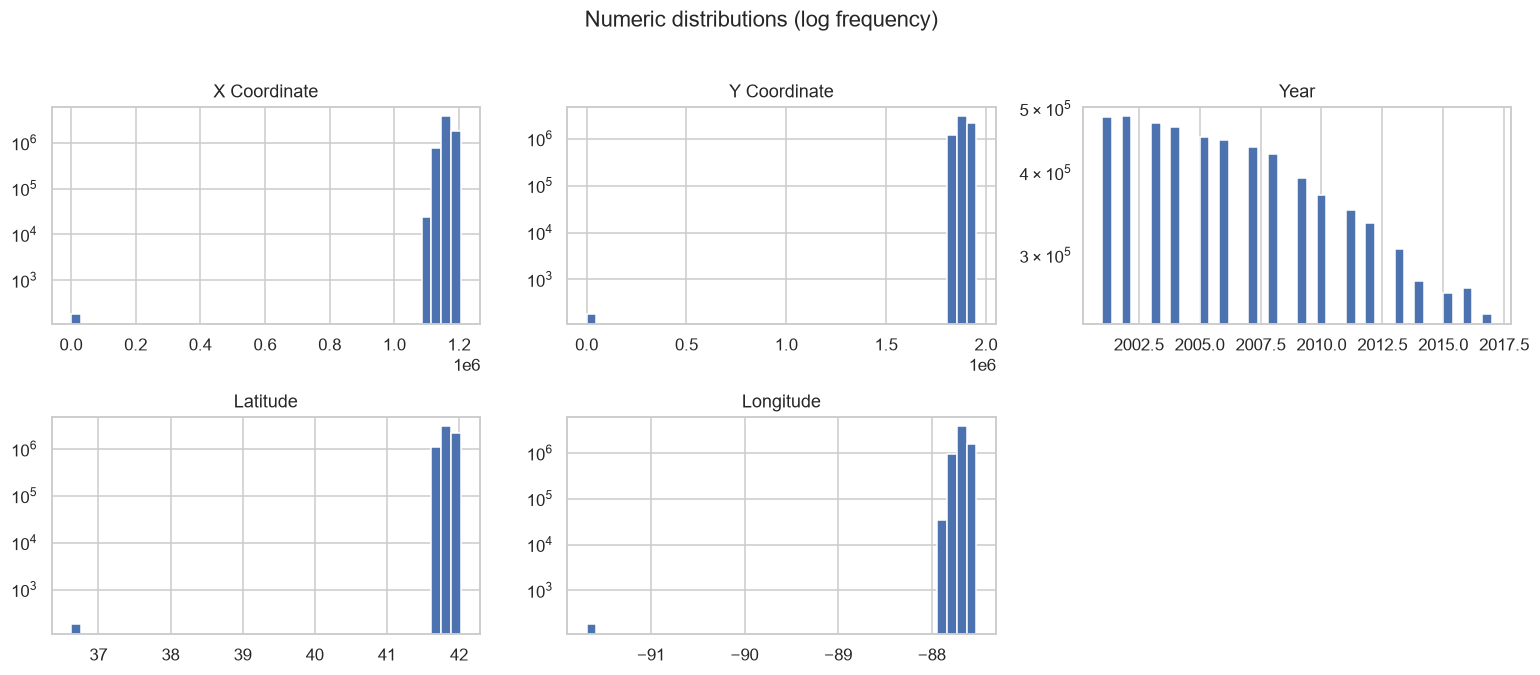

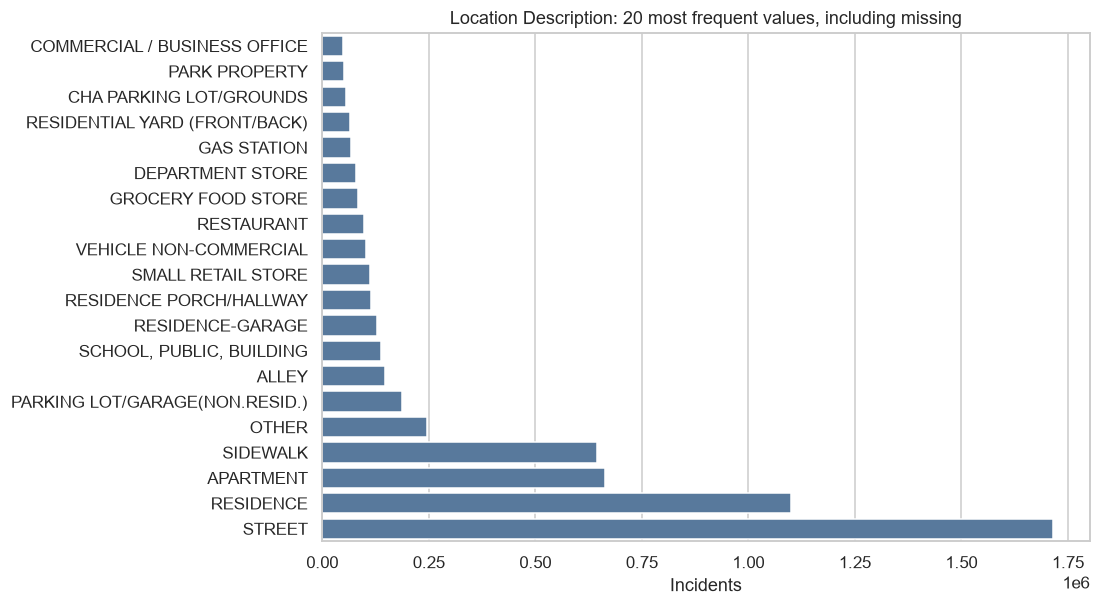

In [4]:
identifier_like = {'ID', 'Case Number', 'FBI Code', 'IUCR', 'Beat', 'District', 'Ward', 'Community Area'}
measure_columns = [c for c in numeric_columns if c not in identifier_like and df[c].nunique() > 10]
if measure_columns:
    ncols = 3; nrows = int(np.ceil(len(measure_columns) / ncols))
    df[measure_columns].hist(bins=40, figsize=(14, 3 * nrows), layout=(nrows, ncols))
    for ax in plt.gcf().axes: ax.set_yscale('log')
    plt.suptitle('Numeric distributions (log frequency)', y=1.02); plt.tight_layout()
for col in [c for c in categorical_with_missing if profile.loc[c, 'unique_non_null'] <= 200]:
    counts = df[col].fillna('Missing').value_counts().head(20).sort_values()
    plt.figure(figsize=(9, max(3, .3 * len(counts))))
    sns.barplot(x=counts.values, y=counts.index, color='#4C78A8')
    plt.title(f'{col}: 20 most frequent values, including missing'); plt.xlabel('Incidents'); plt.ylabel(''); plt.show()

## 4. Monthly and weekly patterns

Counts and arrest counts reproduce the requested monthly view. The arrest rate is the important addition: high volume alone does not imply a higher likelihood of arrest.

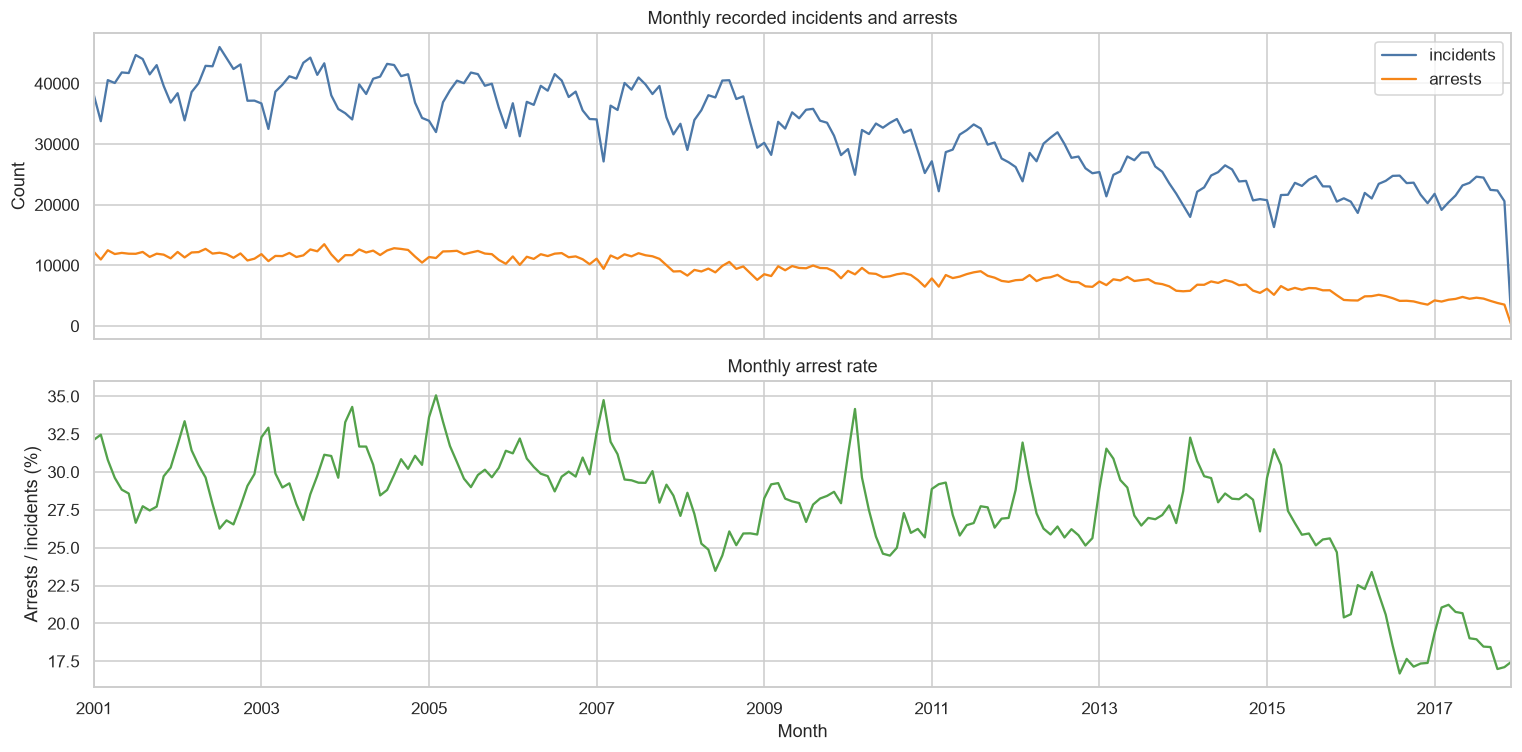

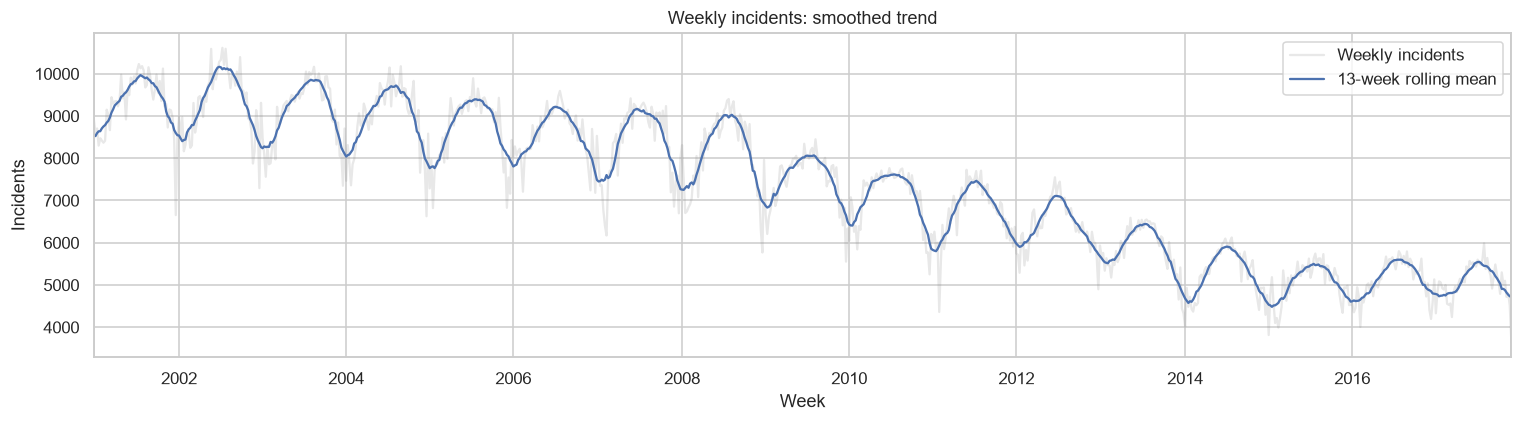

In [5]:
monthly = df.groupby('month').agg(incidents=('ID', 'size'), arrests=('Arrest', 'sum'))
monthly['arrest_rate'] = monthly['arrests'] / monthly['incidents']
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
monthly[['incidents', 'arrests']].plot(ax=axes[0], color=['#4C78A8', '#F58518'])
axes[0].set(title='Monthly recorded incidents and arrests', ylabel='Count')
monthly['arrest_rate'].mul(100).plot(ax=axes[1], color='#54A24B')
axes[1].set(title='Monthly arrest rate', ylabel='Arrests / incidents (%)', xlabel='Month'); plt.tight_layout()
weekly = df.groupby('week').agg(incidents=('ID', 'size'), arrests=('Arrest', 'sum'))
fig, ax = plt.subplots(figsize=(14, 4))
weekly['incidents'].plot(ax=ax, alpha=.18, color='gray', label='Weekly incidents')
weekly['incidents'].rolling(13, center=True, min_periods=1).mean().plot(ax=ax, label='13-week rolling mean')
ax.set(title='Weekly incidents: smoothed trend', ylabel='Incidents', xlabel='Week'); ax.legend(); plt.tight_layout()

## 5. Ward and primary-type comparisons

The violin chart fulfills the ward comparison request. The companion rate chart prevents raw volume from being mistaken for an arrest-probability difference. A heatmap replaces an unreadable all-type line plot.

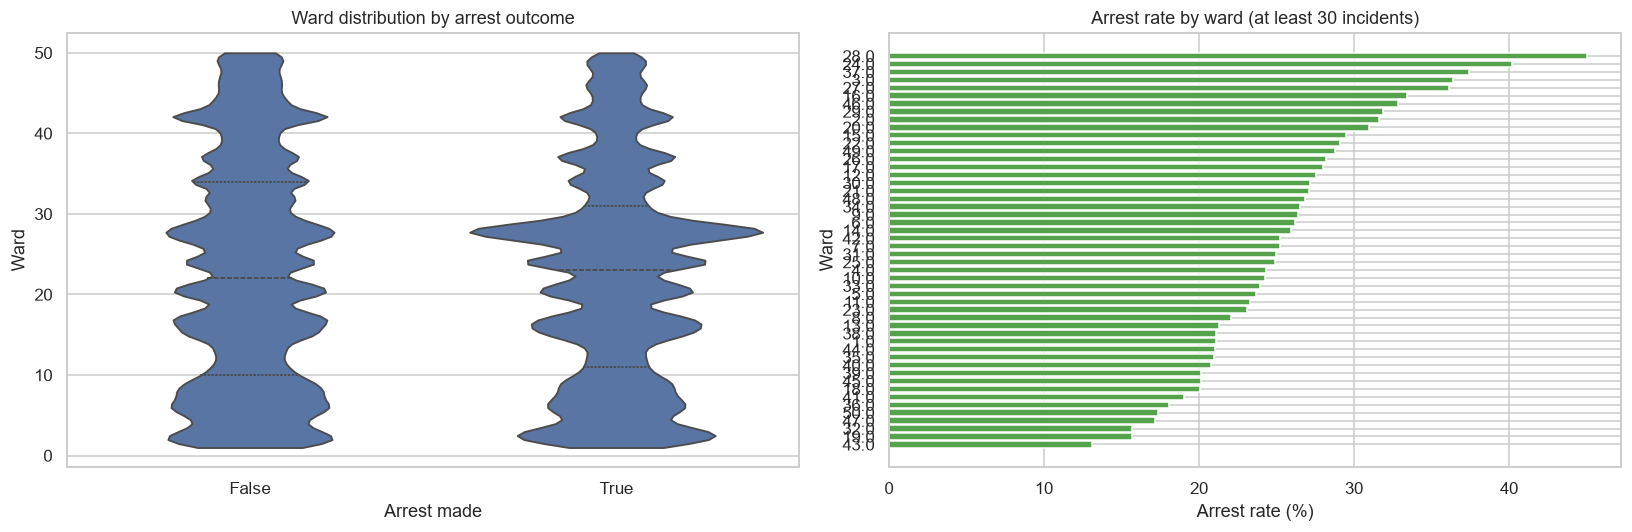

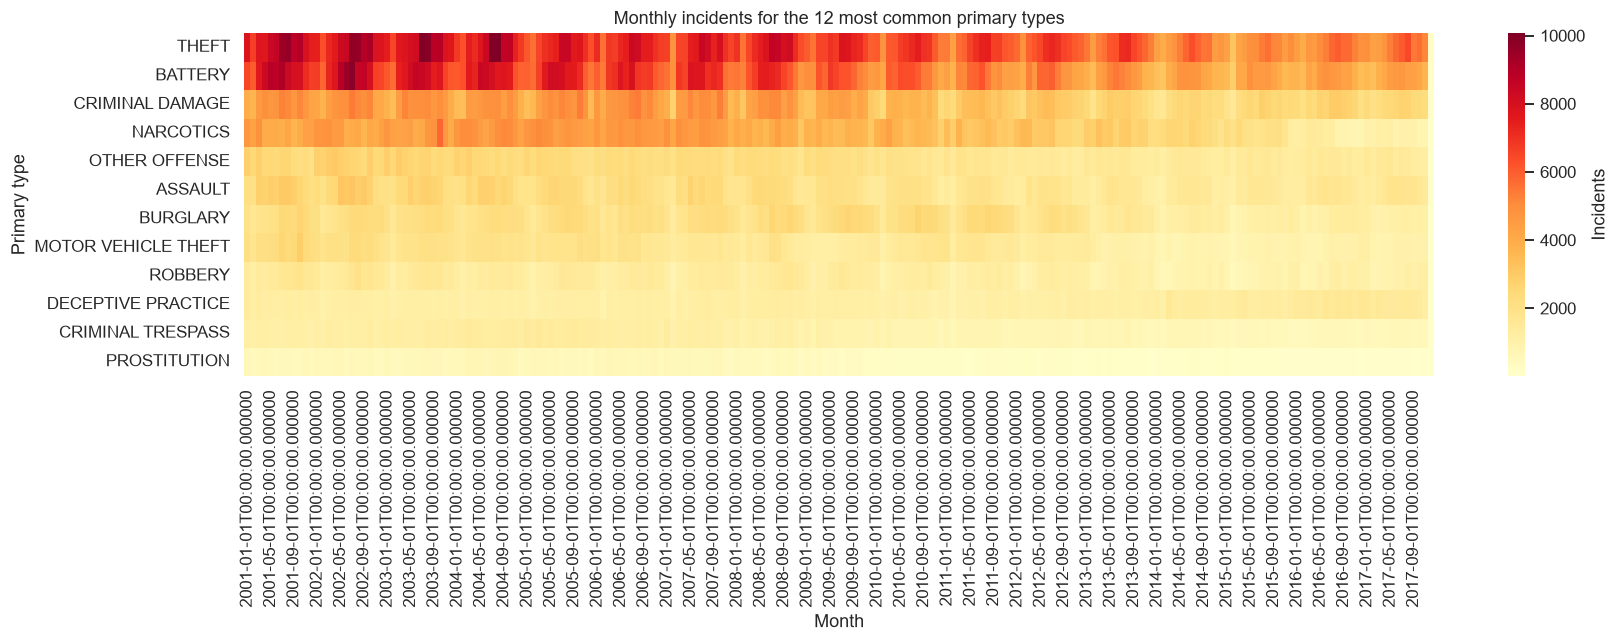

In [6]:
ward_data = df.dropna(subset=['Ward']).copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.violinplot(data=ward_data, x='Arrest', y='Ward', inner='quartile', cut=0, ax=axes[0])
axes[0].set(title='Ward distribution by arrest outcome', xlabel='Arrest made')
ward_summary = ward_data.groupby('Ward').agg(incidents=('ID', 'size'), arrest_rate=('Arrest', 'mean')).query('incidents >= 30').sort_values('arrest_rate')
axes[1].barh(ward_summary.index.astype(str), 100 * ward_summary['arrest_rate'], color='#54A24B')
axes[1].set(title='Arrest rate by ward (at least 30 incidents)', xlabel='Arrest rate (%)', ylabel='Ward'); plt.tight_layout()
top_types = df['Primary Type'].value_counts().head(12).index
type_month = df[df['Primary Type'].isin(top_types)].pivot_table(index='Primary Type', columns='month', values='ID', aggfunc='size', fill_value=0).reindex(top_types)
plt.figure(figsize=(16, 6)); sns.heatmap(type_month, cmap='YlOrRd', cbar_kws={'label': 'Incidents'})
plt.title('Monthly incidents for the 12 most common primary types'); plt.xlabel('Month'); plt.ylabel('Primary type'); plt.tight_layout()

## 6. Coordinates and 25 rotated spatial districts

Zero coordinates are invalid placeholders and must be removed. SVD produces a PCA-style rotation that makes the city more square-like. Five quantile bins on each rotated axis form 25 similarly populated cells, then the heatmap compares every cell over time.

Coordinate correlation: -0.559


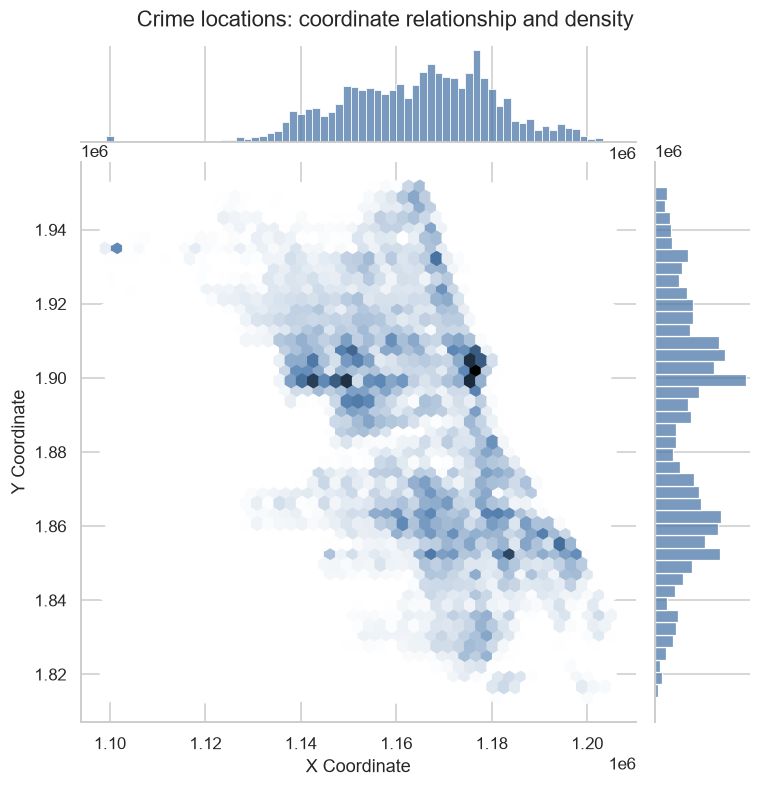

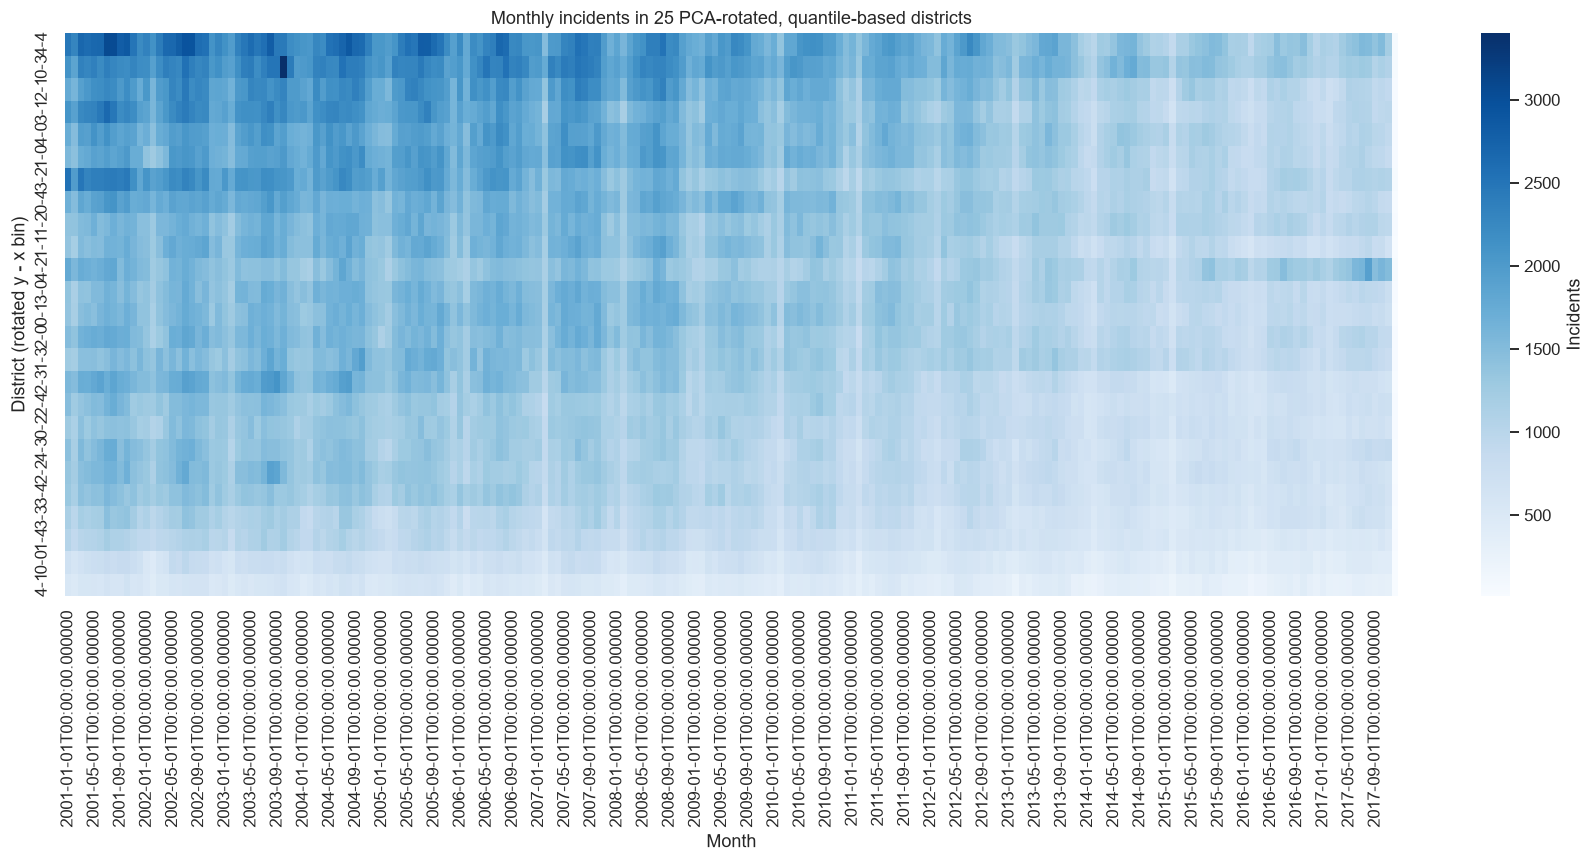

In [7]:
coords = df[['Date', 'month', 'X Coordinate', 'Y Coordinate']].dropna().copy()
coords = coords[(coords['X Coordinate'] != 0) & (coords['Y Coordinate'] != 0)]
xy = coords[['X Coordinate', 'Y Coordinate']].to_numpy(dtype=float)
centered = xy - xy.mean(axis=0)
_, _, vt = np.linalg.svd(centered, full_matrices=False)
coords[['rot_x', 'rot_y']] = centered @ vt.T
sample = coords.sample(min(len(coords), 25000), random_state=42)
g = sns.jointplot(data=sample, x='X Coordinate', y='Y Coordinate', kind='hex', height=7, color='#4C78A8')
g.fig.suptitle('Crime locations: coordinate relationship and density', y=1.02)
print('Coordinate correlation:', round(coords[['X Coordinate', 'Y Coordinate']].corr().iloc[0, 1], 3))
coords['grid_x'] = pd.qcut(coords['rot_x'], 5, labels=False, duplicates='drop')
coords['grid_y'] = pd.qcut(coords['rot_y'], 5, labels=False, duplicates='drop')
coords['district_25'] = coords['grid_y'].astype(str) + '-' + coords['grid_x'].astype(str)
district_month = coords.pivot_table(index='district_25', columns='month', values='Date', aggfunc='size', fill_value=0)
district_order = coords['district_25'].value_counts().index
plt.figure(figsize=(16, 8)); sns.heatmap(district_month.reindex(district_order), cmap='Blues', cbar_kws={'label': 'Incidents'})
plt.title('Monthly incidents in 25 PCA-rotated, quantile-based districts'); plt.xlabel('Month'); plt.ylabel('District (rotated y - x bin)'); plt.tight_layout()

## 7. Data-driven conclusions

The results below update with the source CSV. Interpret recent partial years with caution and do not infer causality from these descriptive comparisons.

In [8]:
peak_month = monthly['incidents'].idxmax()
rate_month = monthly['arrest_rate'].idxmax()
top_type = df['Primary Type'].value_counts().idxmax()
top_district = coords['district_25'].value_counts().idxmax()
peak_incidents = monthly.at[peak_month, 'incidents']
peak_rate = monthly.at[rate_month, 'arrest_rate']
type_share = (df['Primary Type'] == top_type).mean()
first_year = monthly.loc[str(monthly.index.year.min()), 'incidents'].mean()
last_year = monthly.loc[str(monthly.index.year.max()), 'incidents'].mean()
print(f'Highest recorded monthly volume: {peak_incidents:,} incidents in {peak_month:%B %Y}.')
print(f'Overall arrest rate: {df.Arrest.mean():.1%}; highest monthly rate: {peak_rate:.1%} in {rate_month:%B %Y}.')
print(f'Most frequent primary type: {top_type!r}, representing {type_share:.1%} of records.')
print(f'Densest rotated-grid district: {top_district!r}. Use the heatmap to see whether its pattern is persistent.')
print(f'Average monthly volume: {first_year:,.0f} in the first observed year versus {last_year:,.0f} in the last; partial years may bias this comparison.')

Highest recorded monthly volume: 46,013 incidents in July 2002.
Overall arrest rate: 28.0%; highest monthly rate: 35.1% in February 2005.
Most frequent primary type: 'THEFT', representing 20.9% of records.
Densest rotated-grid district: '4-4'. Use the heatmap to see whether its pattern is persistent.
Average monthly volume: 40,478 in the first observed year versus 20,408 in the last; partial years may bias this comparison.
